# Signal Inference with Transformers and Normalising Flows

This notebook provides a **quick start** for running the main experiments in this project, from dataset generation and training to inference and visualisation.
The goal is to infer unknown frequency parameters of sinusoidal signals using Transformer-based models, including probabilistic inference via normalising flows.
We start with a deterministic baseline and then extend the model to probabilistic inference using normalising flows.

## Project overview

The project studies parameter inference for time-series signals of the form:

- single-frequency sine waves
- two-frequency signals (unordered pairs)

We implement:
- a deterministic Transformer model (point prediction)
- a Transformer with a normalising flow head (probabilistic inference)
- an extension to unordered two-frequency targets

The code supports:
- dataset generation
- training and validation
- uncertainty-aware inference
- visualisation of predictions and learned posteriors

## Requirements

- Python 3.12
- PyTorch (CPU or CUDA)
- Packages listed in `requirements.txt`

In [1]:
from main import *

## Quick start: single-frequency inference

This section demonstrates how to:
1. generate a dataset
2. train a Transformer model
3. evaluate predictions on a test set

## Model overview

All models share the same Transformer encoder backbone:
- the input signal is treated as a time sequence
- positional encoding is added to preserve temporal order
- a Transformer encoder processes the sequence
- outputs are pooled over time into a single context vector

The models differ only in the **output head** and the **training objective**.

### Model 1 — Deterministic regression
This trains the baseline Transformer that predicts a single frequency `ω`.

- predicted vs true plot
- training/validation curve plot
- $y(t) = \sin(\omega \cdot t)$

In [2]:
#Reproducibility and device setup
set_seed()
device = set_device()

In [3]:
#Model, loss, optimizer, scheduler
model = TransformerModel1().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

In [4]:
#Dataset generation and conversion to TensorDataset
V_np, tar_np, t_np = make_sine_dataset(noise=True)
ds_full = from_array_to_tensor_dataset(V_np, tar_np)

#Splitting to train, val and test parts
train_loader, val_loader, test_loader = split_and_load(ds_full)

In [5]:
#Training loop with validation-based model selection
model, train_mse_hist, val_mse_hist = train_and_eval_training(train_loader, val_loader, device, model, criterion, optimizer, scheduler)

In [6]:
#Final evaluation on the test set
test_mse, test_mae = evaluate(test_loader, model, device)
print(f"Test MSE {test_mse:.6f}, MAE {test_mae:.6f}")

Test MSE 0.006342, MAE 0.063750


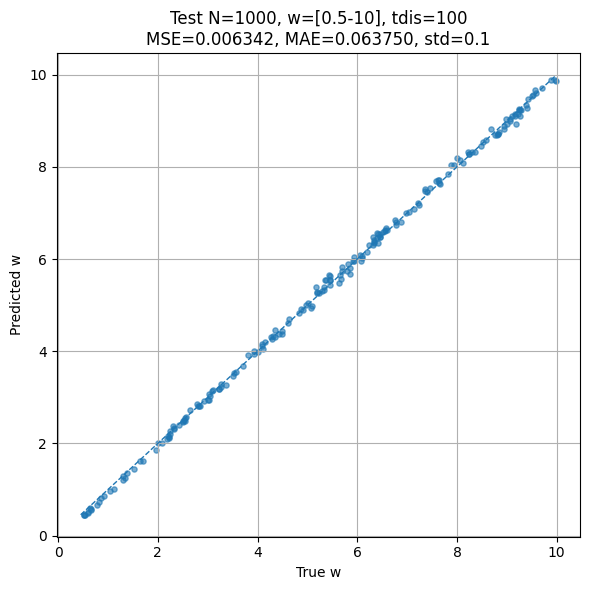

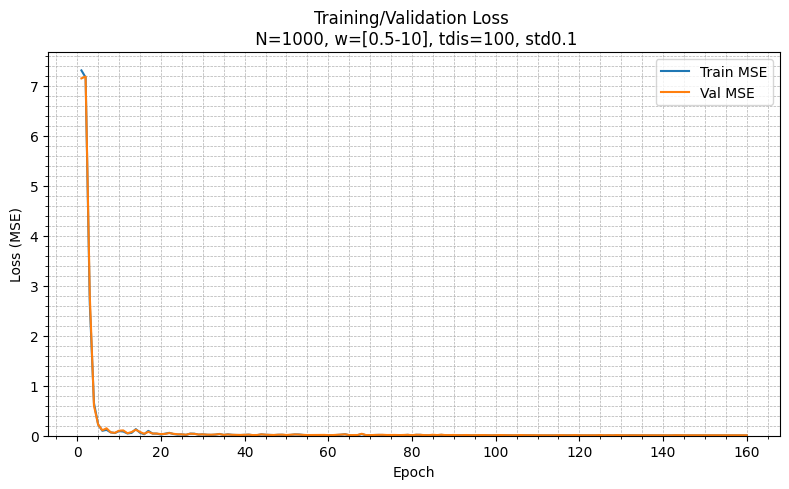

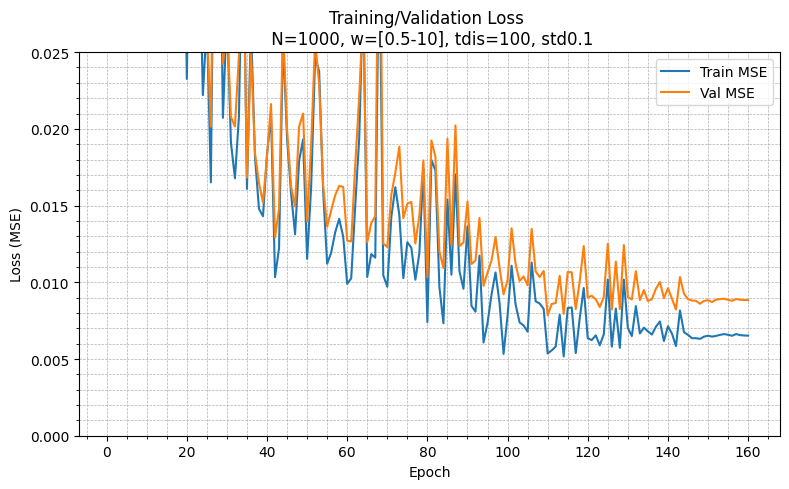

In [7]:
#Collect predictions for visualisation
y_true, y_pred = prediction_collecter_plot(test_loader, model, device)

#Optional plots
plot_pred_vs_true(y_true, y_pred, test_mse, test_mae, show_plot=True)
plot_loss_curves(train_mse_hist, val_mse_hist, show_plot=True)
plot_loss_curves(train_mse_hist, val_mse_hist, show_plot=True, y_limit=0.025)

In [8]:
#All code for model1 above contain function main1(plot1=True, plot2=True) even with plots

### Model 2 — Probabilistic inference with a flow head (single ω)

This model replaces the deterministic regression head with a normalising flow. Instead of predicting a single value, it learns the full conditional distribution p(ω | x).
Training is performed using a negative log-likelihood objective. At inference time, the model can draw samples to estimate uncertainty.
- $y(t) = \sin(\omega \cdot t)$

Test MSE 0.001052, MAE 0.025040


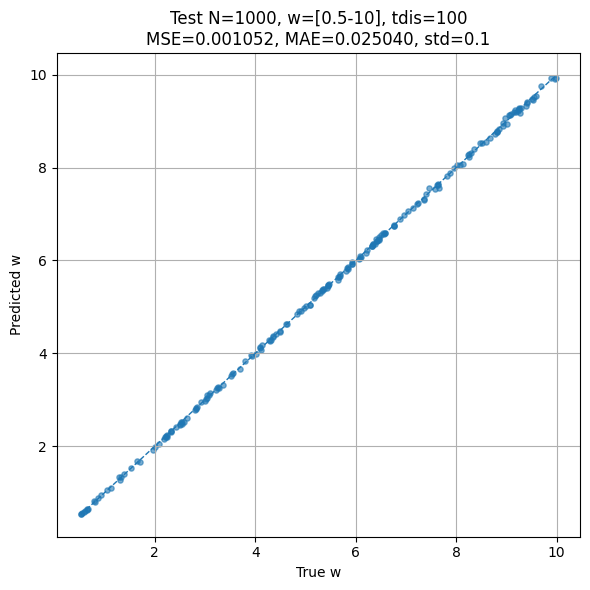

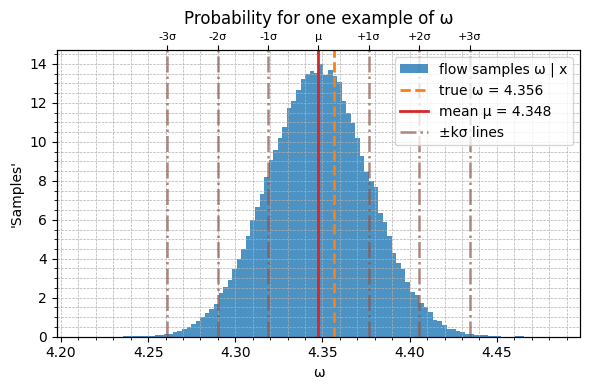

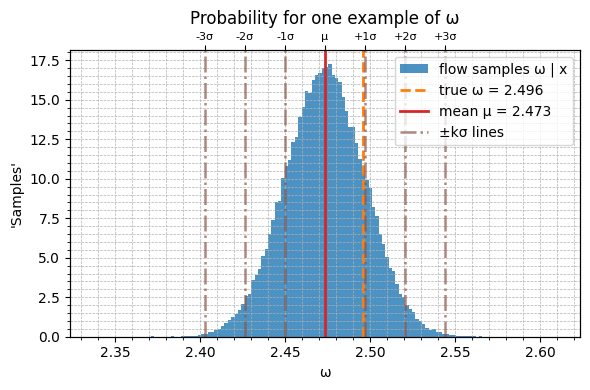

In [9]:
#Train and evaluate the probabilistic single-frequency model
main2()

### Model 3 — Probabilistic inference for two frequencies {ω₁, ω₂}

The final model extends the flow-based approach to signals composed of two frequencies. The targets are treated as unordered pairs {ω₁, ω₂}, and training uses a permutation-invariant objective. This setup allows probabilistic inference over frequency pairs without enforcing an artificial ordering.

Choose the dataset formula using the `dataset=` argument (e.g. `"linear"`, `"nonlinear"`).

- $y(t) = \sin(\omega_1 \cdot t) + \sin(\omega_2 \cdot t)$

Test MSE 0.012059, MAE 0.078588


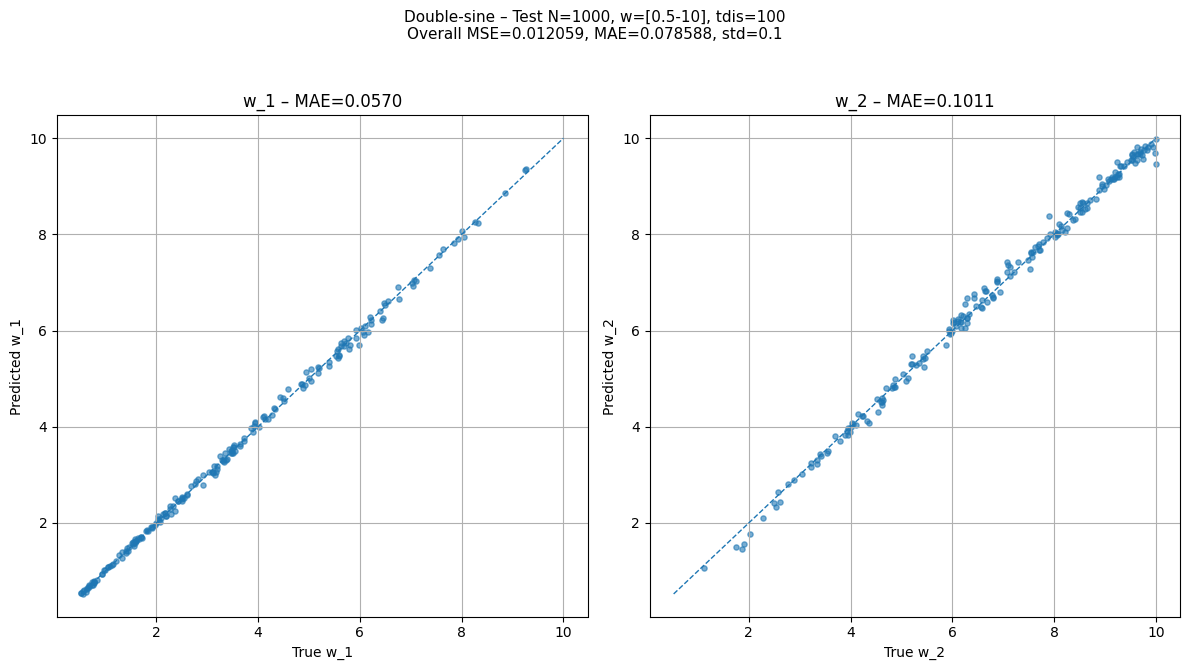

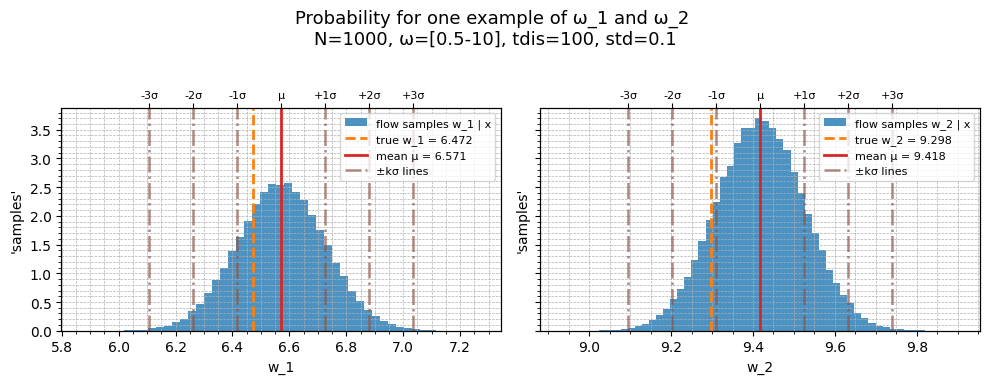

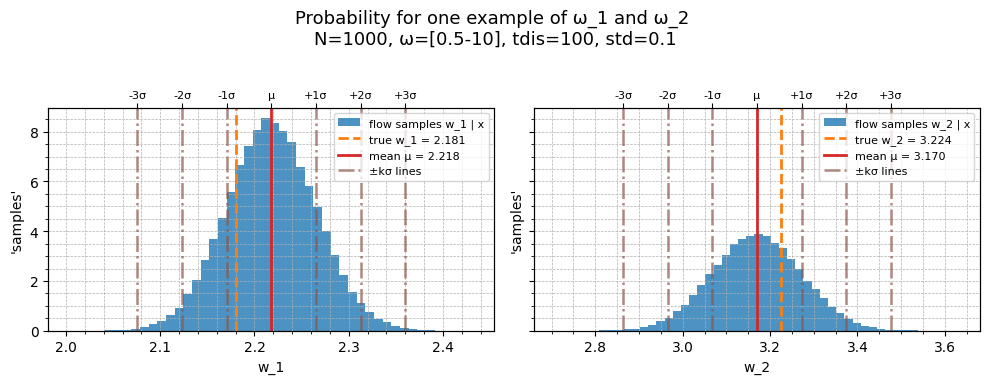

In [10]:
# Train and evaluate the two-frequency probabilistic model (linear dataset)
main3(dataset="linear")

- nonlinear mixture 
- $y(t) = \sin(\omega_1 \cdot t) + \sin(\omega_2 \cdot t) + \sin(\omega_1 \cdot t) \cdot \sin(\omega_2 \cdot t)$

Test MSE 0.013789, MAE 0.087584


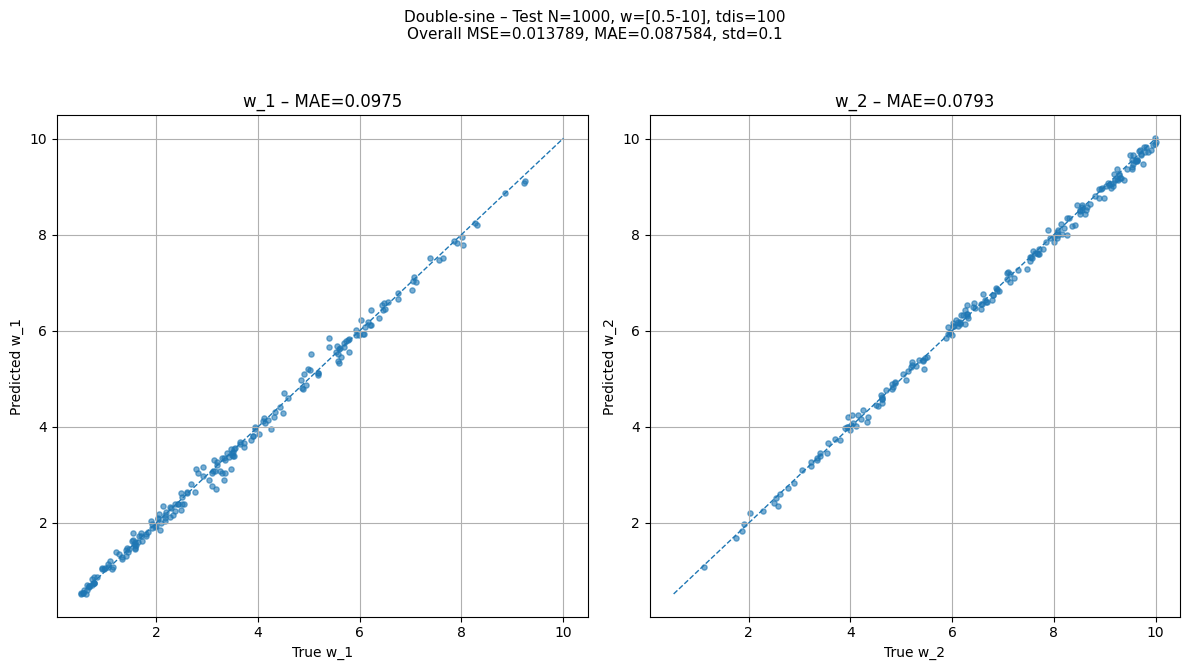

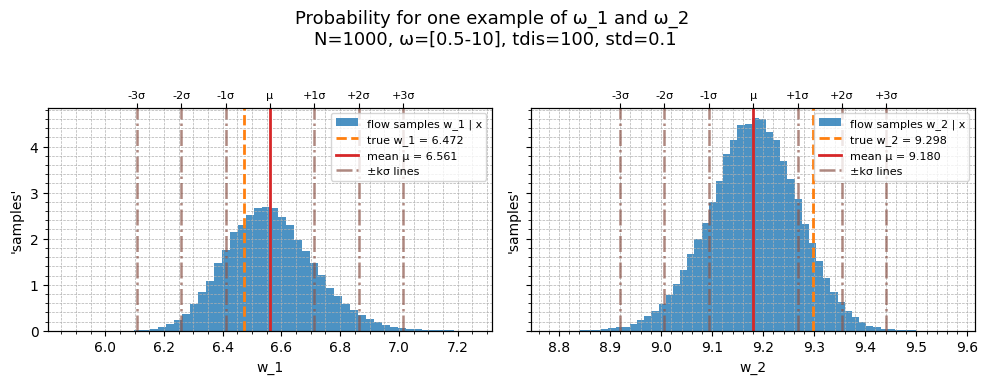

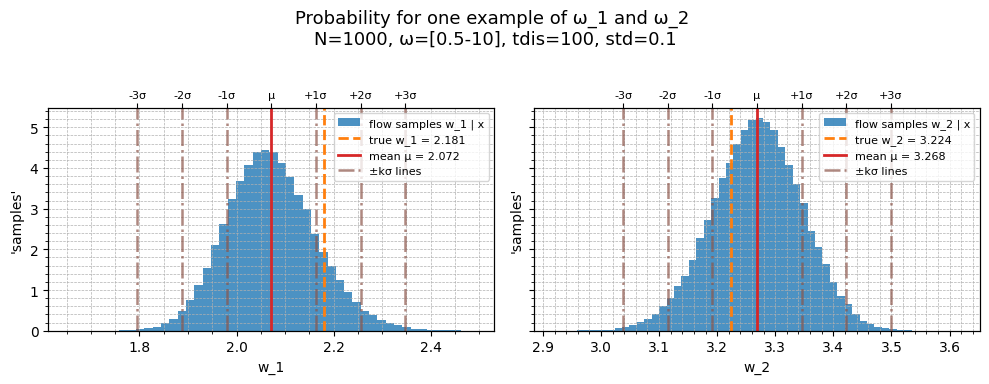

In [11]:
# Train and evaluate the two-frequency probabilistic model (linear dataset)
main3(dataset="nonlinear")

## Notes

- All hyperparameters are defined in `configuration.py`
- The `mainX` functions provide the recommended entry points for running experiments
- Additional analysis and visualisation utilities are available in `visualizations.py`